In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
d = 'enhanced_house_price_dataset.csv'
df = pd.read_csv(d)
df

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4323,1,1,2,0,23,Kolkata,Unfurnished,Yes,Yes,No,Borewell,Yes,Company,6,768553
1996,4803,4,2,1,1,8,Kolkata,Furnished,No,No,Yes,Both,No,Company,2,1117994
1997,5855,5,2,3,0,6,Kolkata,Furnished,No,Yes,No,Borewell,No,Bachelor,4,1800277
1998,2369,3,3,2,2,15,Chennai,Furnished,Yes,No,Yes,Both,Yes,Family,7,1547695


In [12]:
df.shape

(2000, 16)

Data Cleaning

In [13]:
df.isnull().any()

Area                False
Bedrooms            False
Bathrooms           False
Stories             False
Parking             False
Age                 False
City                False
Furnishing          False
Main Road           False
Guest Room          False
Basement            False
Water Supply        False
Air Conditioning    False
Preferred Tenant    False
Locality Rating     False
Price               False
dtype: bool

In [14]:
df.duplicated().any()

np.False_

Data information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Area              2000 non-null   int64 
 1   Bedrooms          2000 non-null   int64 
 2   Bathrooms         2000 non-null   int64 
 3   Stories           2000 non-null   int64 
 4   Parking           2000 non-null   int64 
 5   Age               2000 non-null   int64 
 6   City              2000 non-null   object
 7   Furnishing        2000 non-null   object
 8   Main Road         2000 non-null   object
 9   Guest Room        2000 non-null   object
 10  Basement          2000 non-null   object
 11  Water Supply      2000 non-null   object
 12  Air Conditioning  2000 non-null   object
 13  Preferred Tenant  2000 non-null   object
 14  Locality Rating   2000 non-null   int64 
 15  Price             2000 non-null   int64 
dtypes: int64(8), object(8)
memory usage: 250.1+ KB


In [7]:
df.describe()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,3238.081000,3.031000,2.02150,1.996000,0.990500,24.008500,5.357500,1.245014e+06
std,1604.510239,1.427255,0.81263,0.811981,0.806682,14.319076,2.843015,3.001744e+05
min,401.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,3.346350e+05
25%,1860.000000,2.000000,1.00000,1.000000,0.000000,12.000000,3.000000,1.035278e+06
50%,3271.500000,3.000000,2.00000,2.000000,1.000000,24.000000,5.000000,1.246602e+06
75%,4599.750000,4.000000,3.00000,3.000000,2.000000,36.000000,8.000000,1.453607e+06
max,5996.000000,5.000000,3.00000,3.000000,2.000000,49.000000,10.000000,2.225409e+06


In [9]:
df['Price_per_Area'] = df['Price'] / df['Area']
df['Price_per_Area']

0       1011.388889
1        189.092573
2        265.896374
3        179.474513
4        313.201342
           ...     
1995     177.782327
1996     232.769935
1997     307.476857
1998     653.311524
1999     403.015033
Name: Price_per_Area, Length: 2000, dtype: float64

Research Question 1: Which cities are truly “premium” in terms of housing prices, and are higher prices mainly explained by larger home sizes (Area) or by higher price per area?

In [20]:
city_summary = (
    df.groupby("City")
      .agg(
          Listings=("Price", "count"),
          Median_Price=("Price", "median"),
          Mean_Price=("Price", "mean"),
          Median_Area=("Area", "median"),
          Mean_Area=("Area", "mean"),
          Median_Price_per_Area=("Price_per_Area", "median"),
          Mean_Price_per_Area=("Price_per_Area", "mean"),
      )
      .sort_values("Median_Price", ascending=False)
      .reset_index()
)
city_summary

,City,Listings,Median_Price,Mean_Price,Median_Area,Mean_Area,Median_Price_per_Area,Mean_Price_per_Area
0,Mumbai,319,1297205.0,1.264457e+06,3361.0,3270.203762,384.172511,562.548087
1,Delhi,282,1258940.5,1.257933e+06,3118.5,3156.343972,400.046978,579.324462
2,Kolkata,289,1246587.0,1.252019e+06,3467.0,3392.214533,372.250154,507.708319
3,Pune,285,1243377.0,1.243350e+06,3319.0,3275.810526,366.562849,569.401501
4,Bangalore,263,1242739.0,1.237750e+06,3301.0,3251.646388,385.012241,537.960020
5,Hyderabad,304,1229773.5,1.245889e+06,3306.0,3208.263158,379.355091,571.943404
6,Chennai,258,1189014.0,1.207217e+06,3016.5,3094.678295,382.910277,548.572591


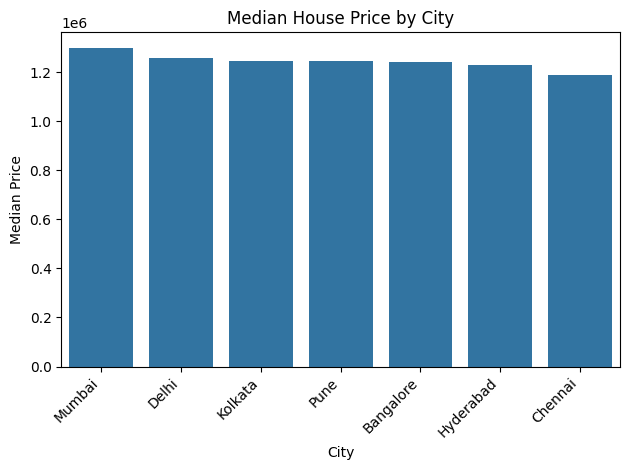

In [23]:
plt.figure()
sns.barplot(x="City", y="Median_Price", data=city_summary)
plt.xticks(rotation=45, ha="right")
plt.xlabel("City")
plt.ylabel("Median Price")
plt.title("Median House Price by City")
plt.tight_layout()
plt.show()

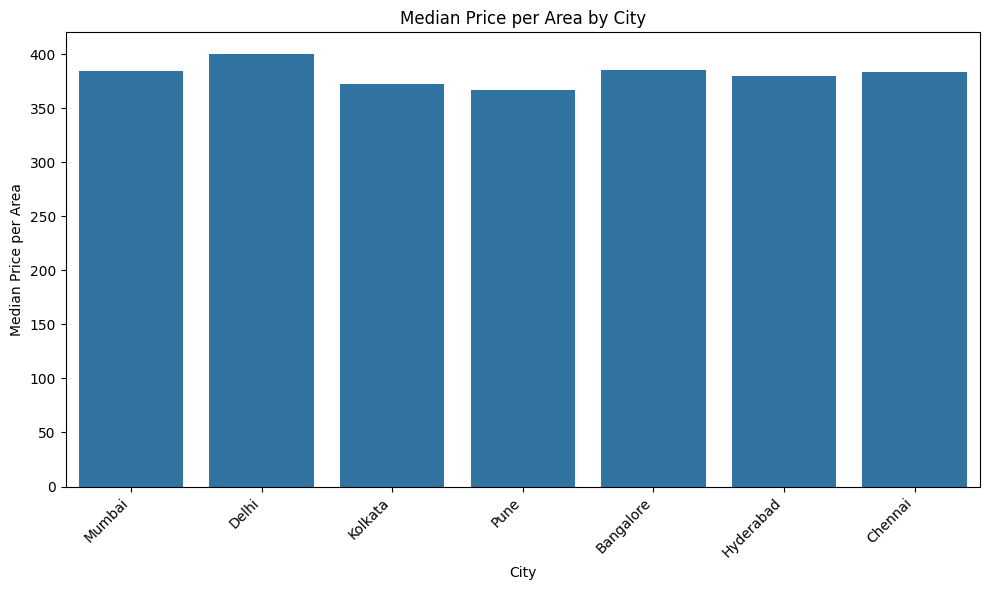

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(x="City", y="Median_Price_per_Area", data=city_summary)
plt.xticks(rotation=45, ha="right")
plt.xlabel("City")
plt.ylabel("Median Price per Area")
plt.title("Median Price per Area by City")
plt.tight_layout()
plt.show()

Findings – Question 1 (Premium cities: big homes vs premium market)
Mumbai has the highest median house price, so it appears the most expensive city overall.
Chennai has the lowest median house price among the cities in the dataset.
When we control for size using Price_per_Area, Delhi ranks highest, meaning it looks like the most “premium per unit area” market (not just bigger homes).
Mumbai’s Price_per_Area is not the highest, suggesting Mumbai is expensive mainly because of overall pricing/size mix, while Delhi shows a stronger unit-price premium.


Research Question 2: Does locality rating have the same relationship with house price across all cities, or does its impact vary by city?

In [7]:
city_rating_summary = (
    df.groupby(["City", "Locality Rating"])
      .agg(
          Listings=("Price", "count"),
          Median_Price=("Price", "median"),
          Mean_Price=("Price", "mean"),
          Median_Price_per_Area=("Price_per_Area", "median"),
      )
      .reset_index()
      .sort_values(["City", "Locality Rating"])
)
city_rating_summary.head(100)

,City,Locality Rating,Listings,Median_Price,Mean_Price,Median_Price_per_Area
0,Bangalore,1,30,1097349.5,1.132843e+06,318.426403
1,Bangalore,2,26,1085053.5,1.081280e+06,313.226009
2,Bangalore,3,28,1224921.5,1.223500e+06,364.567517
3,Bangalore,4,30,1233627.5,1.179187e+06,360.003396
4,Bangalore,5,26,1334568.5,1.336382e+06,417.672786
...,...,...,...,...,...,...
65,Pune,6,23,1272272.0,1.302841e+06,331.569055
66,Pune,7,23,1237385.0,1.276968e+06,622.730490
67,Pune,8,31,1377127.0,1.304488e+06,398.095910
68,Pune,9,34,1362237.0,1.348818e+06,323.668783


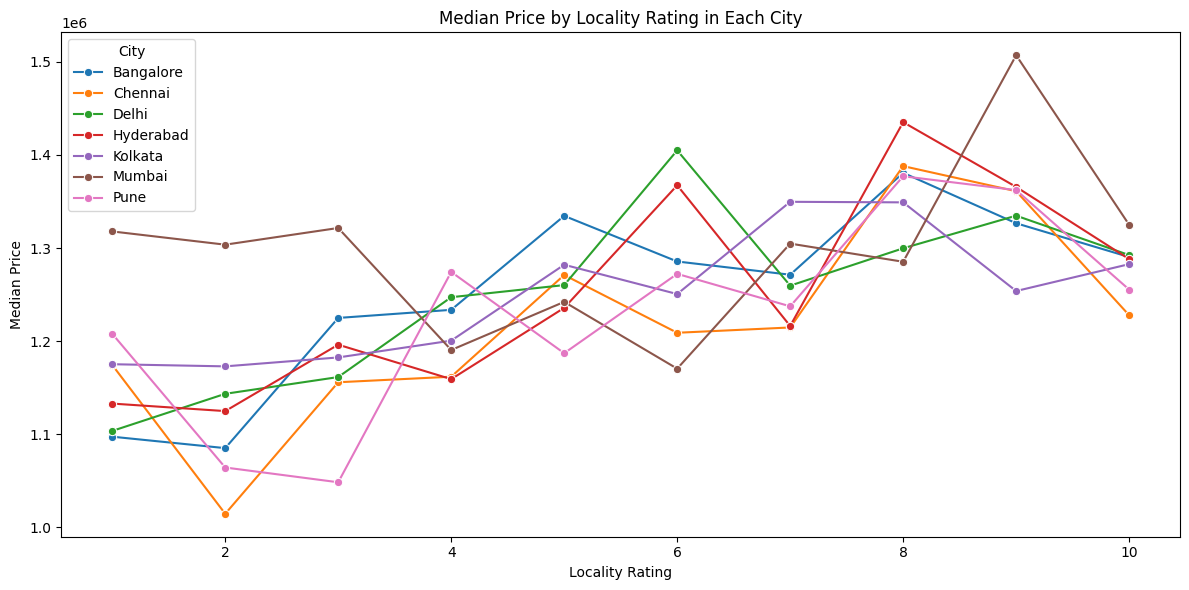

In [24]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=city_rating_summary.head(100),
    x="Locality Rating",
    y="Median_Price",
    hue="City",
    marker="o"
)
plt.title("Median Price by Locality Rating in Each City")
plt.xlabel("Locality Rating")
plt.ylabel("Median Price")
plt.tight_layout()
plt.show()


Trend varies by city: In the line plot, some cities show a clearer upward pattern, while others look more irregular—meaning rating is not equally influential everywhere.

Zig-zag lines happen because medians can be unstable: Some City–Rating combinations likely have fewer listings, so the median price jumps up/down even if the true trend is increasing.

Interpretation: Locality rating matters, but size and property specs (Area/Bedrooms) are still stronger drivers of price than rating alone.

In [11]:
city_corr = (
    df.groupby("City")
      .apply(lambda g: pd.Series({
          "Median_Price": g["Price"].median(),
          "Locality_Rating": g["Locality Rating"].median(),
          "corr": g["Locality Rating"].corr(g["Price"])
      }))
      .reset_index()
      .sort_values("corr", ascending=False)
)

city_corr

C:\Users\MSI\AppData\Local\Temp\ipykernel_14124\271218048.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,City,Median_Price,Locality_Rating,corr
6,Pune,1243377.0,6.0,0.236783
3,Hyderabad,1229773.5,5.0,0.228336
0,Bangalore,1242739.0,5.0,0.220374
2,Delhi,1258940.5,6.0,0.208431
4,Kolkata,1246587.0,5.0,0.185501
5,Mumbai,1297205.0,5.0,0.176793
1,Chennai,1189014.0,5.0,0.176152


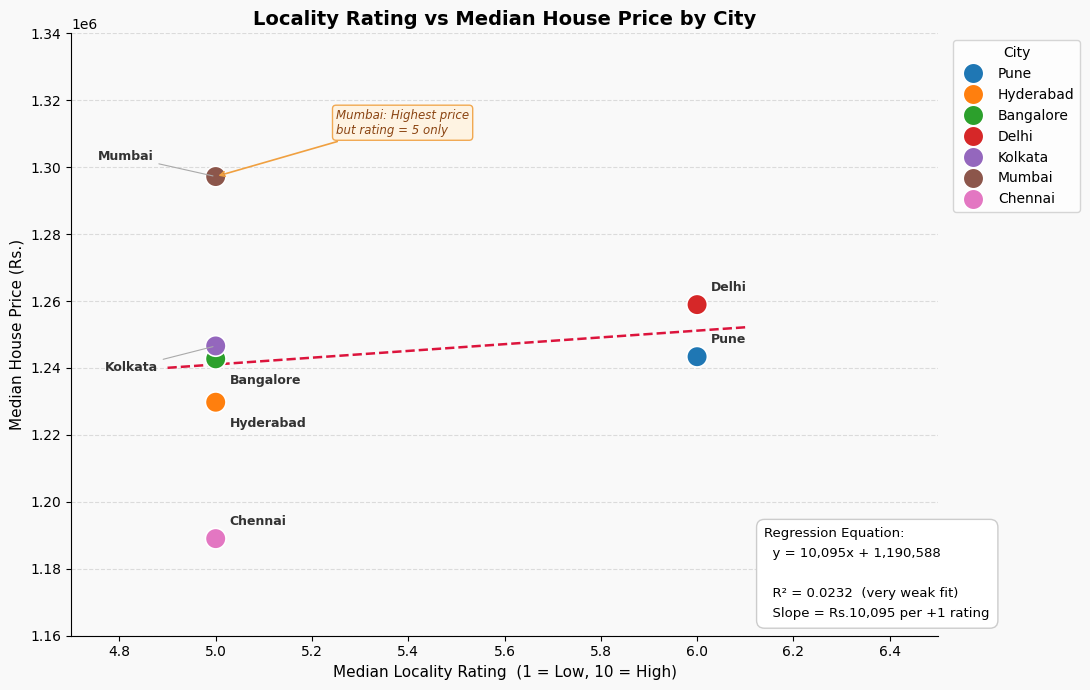

In [26]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f9f9f9')

sns.scatterplot(
    data=city_corr,
    x="Locality_Rating",
    y="Median_Price",
    hue="City",
    s=220,
    edgecolor='white',
    linewidth=1.2,
    zorder=3, ax=ax
)

x = city_corr["Locality_Rating"].values
y = city_corr["Median_Price"].values
a, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min() - 0.1, x.max() + 0.1, 100)
y_line = a * x_line + b
ax.plot(x_line, y_line, color='crimson', linestyle='--', linewidth=1.8)

y_pred = a * x + b
r2 = 1 - (np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2))

# City name labels on each point
offsets = {
    "Mumbai":    (-85, 12),
    "Delhi":     (10,  10),
    "Kolkata":   (-80, -18),
    "Bangalore": (10, -18),
    "Pune":      (10,  10),
    "Hyderabad": (10, -18),
    "Chennai":   (10,  10),
}

for _, row in city_corr.iterrows():
    ox, oy = offsets.get(row["City"], (8, 8))
    ax.annotate(
        row["City"],
        xy=(row["Locality_Rating"], row["Median_Price"]),
        xytext=(ox, oy),
        textcoords="offset points",
        fontsize=9, fontweight='bold', color='#333333',
        arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.8)
            if abs(ox) > 40 else None
    )

# Mumbai special callout
ax.annotate(
    "Mumbai: Highest price\nbut rating = 5 only",
    xy=(5.0, 1297205),
    xytext=(5.25, 1310000),
    fontsize=8.5, color='#8B4513', fontstyle='italic',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#fff3e0", edgecolor="#f0a040", alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='#f0a040', lw=1.2)
)

# Stats box
stats_text = (f"Regression Equation:\n"
              f"  y = {a:,.0f}x + {b:,.0f}\n\n"
              f"  R² = {r2:.4f}  (very weak fit)\n"
              f"  Slope = Rs.{a:,.0f} per +1 rating")
ax.text(0.80, 0.18, stats_text, transform=ax.transAxes, va="top", fontsize=9.5,
        linespacing=1.7,
        bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="#cccccc"))




ax.set_title("Locality Rating vs Median House Price by City", fontsize=14, fontweight='bold')
ax.set_xlabel("Median Locality Rating  (1 = Low, 10 = High)", fontsize=11)
ax.set_ylabel("Median House Price (Rs.)", fontsize=11)

ax.set_xlim(4.7, 6.5)
ax.set_ylim(1_160_000, 1_340_000)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title="City", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

🏙️ City identity dominates pricing — geography is the strongest and most consistent price determinant across all markets
📍 Locality rating is a statistically real but practically limited signal — it moves prices in the right direction, but never decisively
💰 Premium markets are rating-insensitive—Mumbai buyers price in scarcity and demand, not locality scores
📊 Price is a multivariate outcome — no single feature is sufficient; area, amenities, and city tier collectively drive valuation

Research Question 3: What is the price premium associated with key amenities (Furnishing, Air Conditioning, Basement, Guest Room), and does the premium differ depending on the preferred tenant type (Bachelor, Family, Company)?

In [6]:
amenities = ["Furnishing", "Air Conditioning", "Basement", "Guest Room"]

amenity_summary_list = []

for a in amenities:
    tmp = (
        df.groupby(a)
          .agg(
              Listings=("Price", "count"),            
              Median_Price=("Price", "median"),
              Mean_Price=("Price", "mean"),
              Median_Price_per_Area=("Price_per_Area", "median"),
          )
          .reset_index()
          .rename(columns={a: "Category"})           
    )
    tmp.insert(0, "Amenity", a)
    amenity_summary_list.append(tmp)

amenity_summary = pd.concat(amenity_summary_list, ignore_index=True)


amenity_summary

,Amenity,Category,Listings,Median_Price,Mean_Price,Median_Price_per_Area
0,Furnishing,Furnished,668,1308073.5,1.318926e+06,411.333559
1,Furnishing,Semi-Furnished,696,1261360.5,1.260307e+06,380.897055
2,Furnishing,Unfurnished,636,1166698.5,1.150646e+06,355.074895
3,Air Conditioning,No,996,1187158.5,1.188857e+06,365.945049
4,Air Conditioning,Yes,1004,1305381.5,1.300723e+06,398.921679
5,Basement,No,1030,1218234.5,1.222728e+06,376.351237
6,Basement,Yes,970,1269243.0,1.268677e+06,391.890290
7,Guest Room,No,984,1208928.0,1.215930e+06,387.866115
8,Guest Room,Yes,1016,1275233.0,1.273181e+06,379.500050


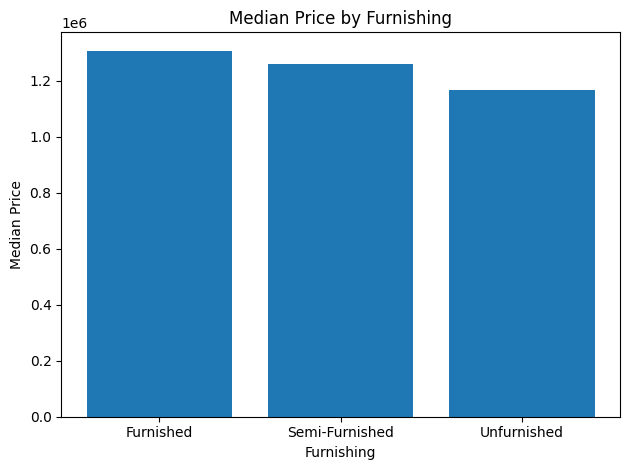

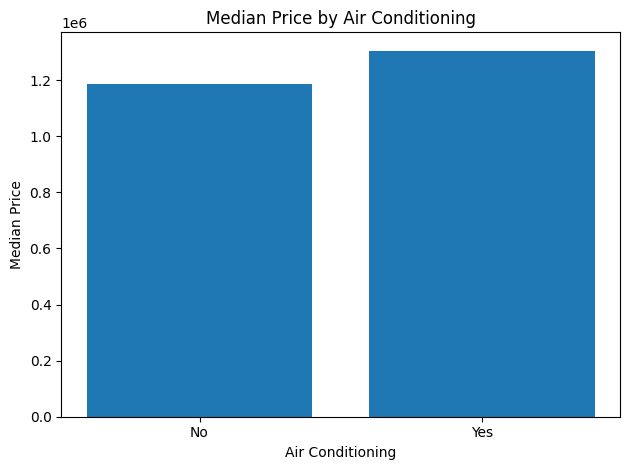

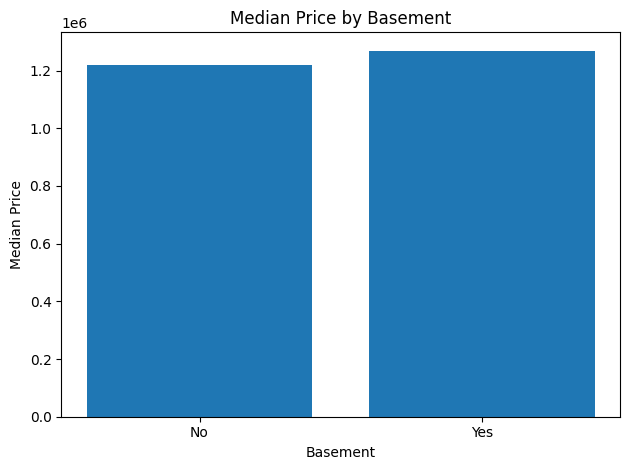

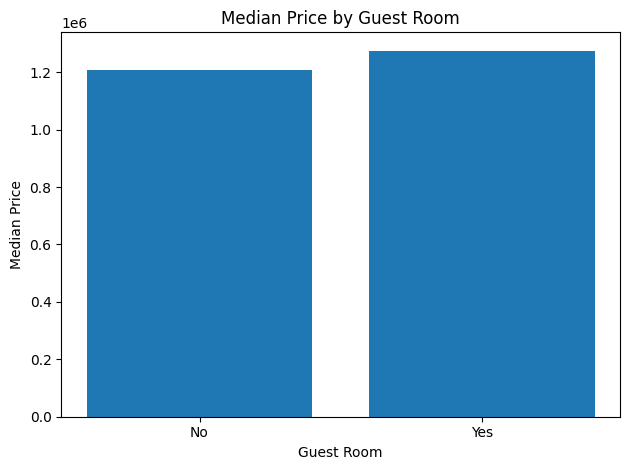

In [30]:
for a in amenities:
    tmp = amenity_summary[amenity_summary["Amenity"] == a].copy()

    plt.figure()
    plt.bar(tmp[a].astype(str), tmp["Median_Price"])
    plt.xlabel(a)
    plt.ylabel("Median Price")
    plt.title(f"Median Price by {a}")
    plt.tight_layout()
    plt.show()

Graph 1: Furnishing vs Median Price
Furnished homes show a higher median price than semi-furnished and unfurnished listings.
This suggests furnishing level is associated with a price premium, likely because it adds convenience and move-in readiness.

Graph 2: Air Conditioning (Yes/No) vs Median Price
Homes with Air Conditioning = Yes tend to have a higher median price than those without.
This indicates AC is a value-adding amenity, especially in warmer cities/areas.

Graph 3: Basement (Yes/No) vs Median Price
Listings with a Basement = Yes generally have a higher median price than those without.
Basement presence may act as a proxy for larger properties or additional usable space.


In [ ]:
amenity_tenant_list = []

for a in amenities:
    tmp = (
        df.groupby([a, "Preferred Tenant"])
          .agg(
              Listings=("Price", "count"),              
              Median_Price=("Price", "median"),
              Mean_Price=("Price", "mean"),
              Median_Price_per_Area=("Price_per_Area", "median"),
          )
          .reset_index()
          .rename(columns={a: "Category"})             
    )
    tmp.insert(0, "Amenity", a)
    amenity_tenant_list.append(tmp)

amenity_by_tenant = (
    pd.concat(amenity_tenant_list, ignore_index=True)
      .sort_values(["Amenity", "Category", "Preferred Tenant"])
      .reset_index(drop=True)
)


amenity_by_tenant


,Amenity,Category,Preferred Tenant,Listings,Median_Price,Mean_Price,Median_Price_per_Area
0,Air Conditioning,No,Bachelor,357,1187299.0,1.182484e+06,363.486199
1,Air Conditioning,No,Company,332,1174733.0,1.191195e+06,375.823734
2,Air Conditioning,No,Family,307,1206603.0,1.193739e+06,360.196525
3,Air Conditioning,Yes,Bachelor,356,1321036.5,1.316264e+06,411.333559
4,Air Conditioning,Yes,Company,341,1311017.0,1.295558e+06,389.118721
5,Air Conditioning,Yes,Family,307,1279273.0,1.288438e+06,396.434361
6,Basement,No,Bachelor,391,1218218.0,1.221914e+06,377.446682
7,Basement,No,Company,330,1228671.0,1.233992e+06,386.986241
8,Basement,No,Family,309,1211203.0,1.211730e+06,366.634790
9,Basement,Yes,Bachelor,322,1293467.5,1.282511e+06,398.263110


<Figure size 800x600 with 0 Axes>

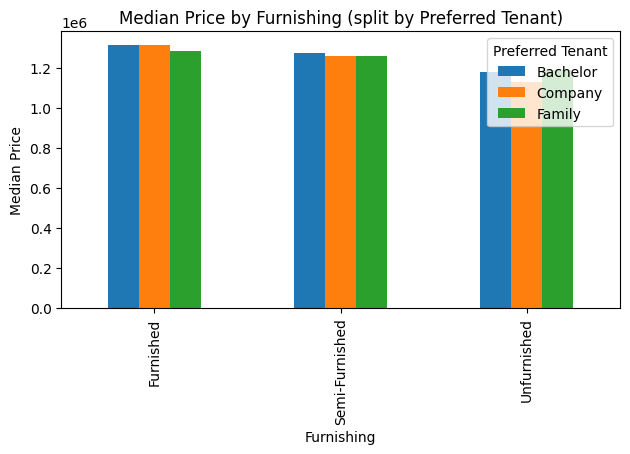

<Figure size 800x600 with 0 Axes>

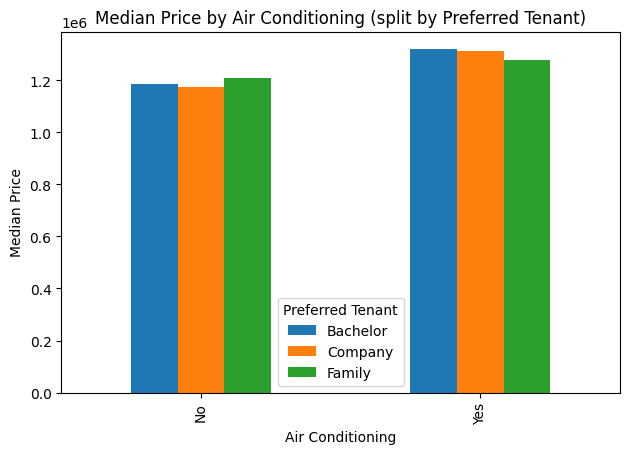

<Figure size 800x600 with 0 Axes>

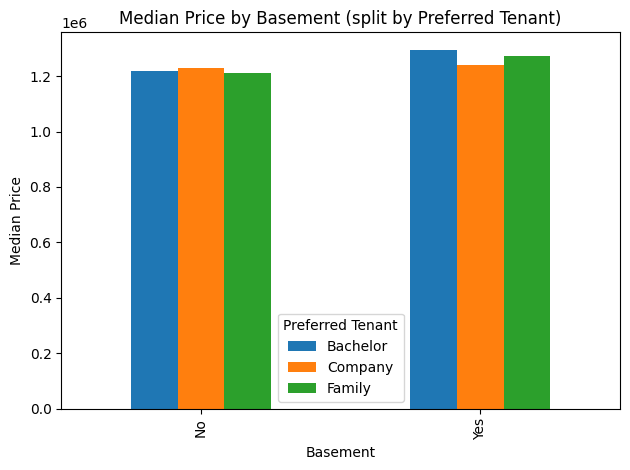

<Figure size 800x600 with 0 Axes>

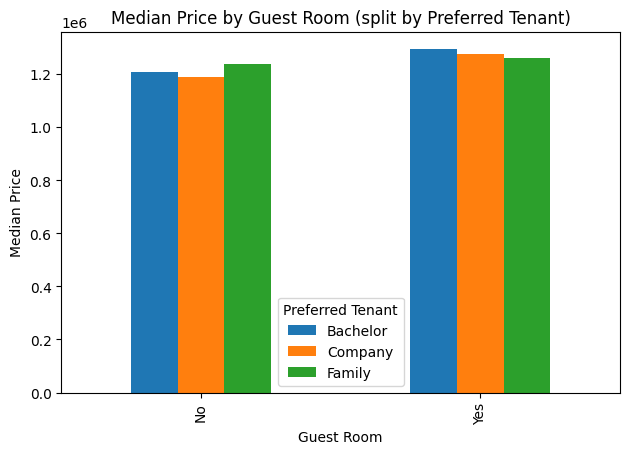

In [34]:
for a in amenities:
    tmp = amenity_by_tenant[amenity_by_tenant["Amenity"] == a].copy()

    pivot = tmp.pivot(index=a, columns="Preferred Tenant", values="Median_Price")

    plt.figure(figsize=(8, 6))
    pivot.plot(kind="bar")  # default colors
    plt.xlabel(a)
    plt.ylabel("Median Price")
    plt.title(f"Median Price by {a} (split by Preferred Tenant)")
    plt.tight_layout()
    plt.show()

Graph 5 (Grouped Bar): Amenity × Preferred Tenant
The price premium for amenities is not the same across tenant types (Bachelor vs Family vs Company).
In many cases, Company and Family-targeted listings show higher median prices for the same amenity level than Bachelor listings.
This suggests the market may price amenities differently depending on the target tenant segment.


Research Question 4: How do core property specifications (Area, Bedrooms, Bathrooms, Stories, Parking, Age) relate to house price, and which numeric variables show the strongest correlations with price?

In [15]:
df["Main_Road_Bin"] = df["Main Road"].map({"Yes": 1, "No": 0})

num_cols = ["Price", "Area", "Bedrooms", "Bathrooms", "Stories", "Parking",
            "Age", "Locality Rating", "Price_per_Area", "Main_Road_Bin"]

corr_series = df[num_cols].corr(numeric_only=True).loc["Price"].sort_values(ascending=False)

corr_df = corr_series.reset_index()
corr_df.columns = ["Variable", "Correlation_with_Price"]

corr_df

,Variable,Correlation_with_Price
0,Price,1.000000
1,Bedrooms,0.600588
2,Area,0.339137
3,Bathrooms,0.267506
4,Locality Rating,0.205792
5,Stories,0.205615
6,Parking,0.159216
7,Main_Road_Bin,0.094667
8,Price_per_Area,0.031257
9,Age,-0.056614


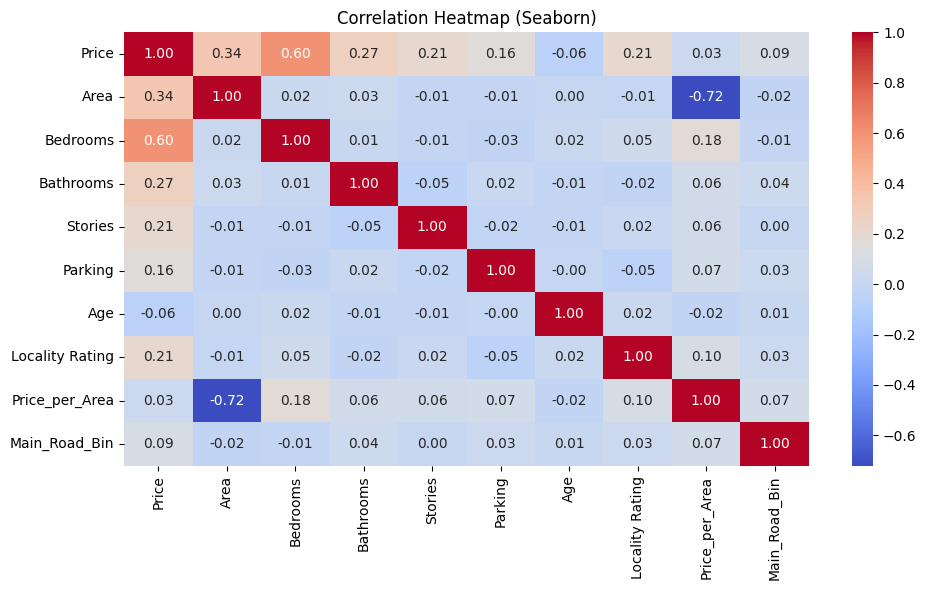

In [14]:
corr_matrix = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Seaborn)")
plt.tight_layout()
plt.show()

Bedrooms has the strongest positive relationship with Price in this dataset (corr ≈ 0.60), meaning homes with more bedrooms tend to be priced higher.
Area shows a moderate positive correlation with Price (corr ≈ 0.34), confirming that larger homes generally cost more.
Bathrooms has a smaller positive relationship with Price (corr ≈ 0.27), suggesting bathrooms add value but less strongly than bedrooms/area.
Stories and Locality Rating show weak positive relationships with Price (both around corr ≈ 0.21), meaning they influence price but are not the main drivers.
Parking has a weak positive correlation with Price (corr ≈ 0.16), so it adds some value but not strongly.
Age has a very weak negative relationship with Price (corr ≈ -0.06), meaning older houses are slightly cheaper on average, but the effect is small.
Overall, the visuals (scatter + trend line) confirm price increases with area and bedrooms, while other variables have weaker and noisier patterns

Research Question 5: What combination of features characterizes the top 10% most expensive homes, and how do these premium homes differ from the bottom 90% in terms of size, location quality, and amenities?

In [ ]:
threshold = df["Price"].quantile(0.90)
df["Price_Segment"] = np.where(df["Price"] >= threshold, 
                               "Top 10% (Premium)", "Bottom 90%")

threshold, df["Price_Segment"].value_counts()


(np.float64(1630452.9000000001),
 Price_Segment
 Bottom 90%           1800
 Top 10% (Premium)     200
 Name: count, dtype: int64)

In [ ]:
q5_num_cols = ["Price", "Area", "Bedrooms", "Bathrooms", "Stories",
               "Parking", "Age", "Locality Rating", "Price_per_Area"]

q5_numeric = df.groupby("Price_Segment")[q5_num_cols].median().reset_index()
q5_numeric


,Price_Segment,Price,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price_per_Area
0,Bottom 90%,1205149.5,3137.0,3.0,2.0,2.0,1.0,24.0,5.0,382.450333
1,Top 10% (Premium),1736365.5,4591.5,5.0,3.0,2.0,1.0,22.5,7.0,389.302252


In [ ]:
med = df.groupby("Price_Segment")[["Price", "Area", "Bedrooms"
                                   , "Bathrooms", "Stories",
               "Parking", "Age", 
               "Locality Rating", "Price_per_Area"]
].median()

bottom = med.loc["Bottom 90%"]
top = med.loc["Top 10% (Premium)"]

uplift_pct = ((top - bottom) / bottom) * 100
uplift_df = uplift_pct.reset_index()
uplift_df.columns = ["Variable", "Premium_vs_Bottom90_%"]
uplift_df




,Variable,Premium_vs_Bottom90_%
0,Price,44.078847
1,Area,46.365955
2,Bedrooms,66.666667
3,Bathrooms,50.000000
4,Stories,0.000000
5,Parking,0.000000
6,Age,-6.250000
7,Locality Rating,40.000000
8,Price_per_Area,1.791584


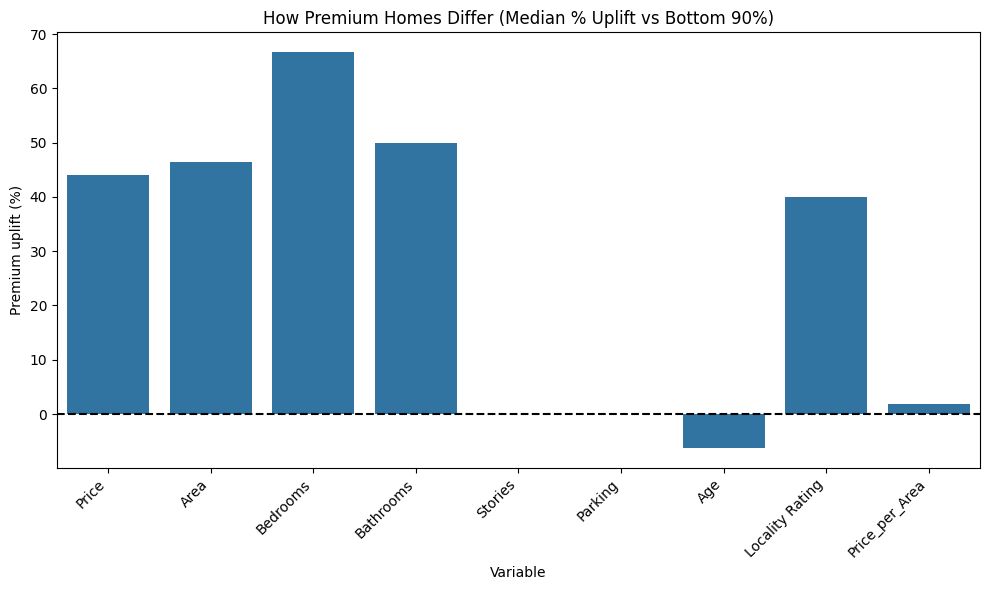

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(x="Variable", y="Premium_vs_Bottom90_%", data=uplift_df)
plt.xticks(rotation=45, ha="right")
plt.axhline(0, color='black', linestyle='--')
plt.ylabel("Premium uplift (%)")
plt.title("How Premium Homes Differ (Median % Uplift vs Bottom 90%)")

plt.tight_layout()
plt.show()

Split homes into Top 10% (Premium) vs Bottom 90% using the 90th percentile price threshold.

Premium homes have much higher medians for Area, Bedrooms, and Bathrooms (bigger homes with more rooms).

Premium homes also show higher Locality Ratings, indicating better locations.

Premium listings tend to include more desirable amenities (e.g., furnishing/AC/extra rooms).

Price per Area is nearly similar between groups, suggesting premium homes are expensive mainly because they are larger and better equipped, not because unit price is much higher.